# Importar librerías

In [1]:
import sys
from pathlib import Path

# encontrar raíz del proyecto (carpeta que contiene "src")
root = Path().resolve()
while not (root / "src").exists():
    root = root.parent

sys.path.append(str(root))

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, roc_curve
import matplotlib.pyplot as plt
from src.data.load_data import cargar_csv
from src.models.predict import predict_churn
import pandas as pd

# Cargar base de datos

In [3]:
ruta_archivo = '../databases/processed/data_test.csv'

In [4]:
data_test = cargar_csv(ruta_archivo)
data_test.head()

,customer_id,churn_label,monthly_spend,total_shipments,customer_tenure_days,days_since_last_purchase,shipments_per_month,spend_per_shipment
0,C002,0,1200.0,45,1110,300,1.184211,26.086957
1,C003,1,3435.0,8,1097,346,0.212955,381.666667
2,C004,0,890.2,22,1059,278,0.606061,38.704348
3,C018,0,1500.0,60,724,356,2.387268,24.590164
4,C021,1,340.0,8,690,389,0.333333,37.777778


# Predicción y evaluación del modelo

In [5]:
variables = ['monthly_spend', 'total_shipments', 'customer_tenure_days', 'days_since_last_purchase',
             'shipments_per_month', 'spend_per_shipment']
X = data_test[variables]
y = data_test["churn_label"]

In [6]:
# 2. Escalado de variables numéricas
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
prediction, probability = predict_churn('../churn_model', X)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


In [8]:
prediction

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0])

In [9]:
probability

array([7.0214063e-02, 3.0830592e-01, 2.4050301e-01, 5.6689773e-02,
       8.9487308e-01, 1.8750060e-01, 8.3630806e-01, 1.3197193e-01,
       2.7333600e-02, 3.7545761e-01, 5.0937291e-02, 7.8484458e-01,
       2.3603230e-04, 1.5259330e-02, 7.6605499e-01, 4.4919800e-02,
       5.6303460e-02, 7.9779655e-01, 5.7825390e-02, 1.2519539e-02,
       3.5747387e-02, 1.2842235e-01, 2.5445532e-02, 3.6672615e-02,
       8.0700040e-01, 3.8097399e-01, 4.9661482e-03, 5.8616389e-02,
       4.7088331e-01, 9.7570437e-01, 9.9278915e-01, 5.8997881e-02,
       2.6606533e-03], dtype=float32)

In [10]:
print(classification_report(y,prediction))
print("ROC AUC:", roc_auc_score(y,probability))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        25
           1       0.88      0.88      0.88         8

    accuracy                           0.94        33
   macro avg       0.92      0.92      0.92        33
weighted avg       0.94      0.94      0.94        33

ROC AUC: 0.97


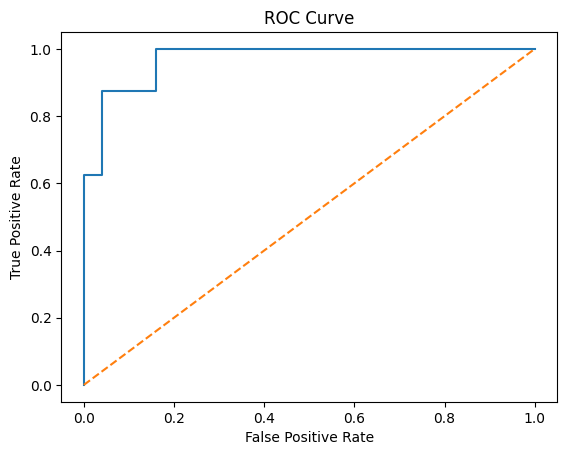

In [11]:
fpr, tpr, _ = roc_curve(y, probability)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig(f"../imagenes/roc_auc_pred_nuevos_datos.png", bbox_inches="tight")
plt.show()

In [12]:
confusion_matrix(y, prediction)

array([[24,  1],
       [ 1,  7]])

In [13]:
predicciones = pd.concat([data_test[['customer_id','churn_label']],
                          pd.DataFrame(prediction, columns=['churn_label_pred']),
                          pd.DataFrame(probability, columns=['churn_label_pred_prob'])], axis=1)

In [14]:
predicciones.to_csv('../databases/predictions/predicciones.csv', sep=',', index=False)